### **Cleaning data**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_pipeline import cleaning_data
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
def read_data():
    df=pd.read_csv(r"C:\Users\LOQ\Downloads\Exercise\ADY\house-prices-advanced-regression-techniques\train.csv")
    X_clean,y_clean=cleaning_data(df)

    le_dict = {}
    categorical_cols = X_clean.select_dtypes(include=['object'])
    for col in categorical_cols.columns:
        # global le
        le = OrdinalEncoder()
        X_clean[col] = le.fit_transform(X_clean[[col]])
        le_dict[col] = le

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean,
        y_clean,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )
    return X_train, X_test, y_train, y_test,le_dict

## **Random Forest**

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

C:\Users\LOQ\AppData\Local\Temp\ipykernel_23928\1382494781.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_clean.select_dtypes(include=['object'])


--------------------------------------------------
✅ R2 Score: 0.8923
MAE (Mean Absolute Error): 17,195 USD
RMSE (Root Mean Squared Error): 28,745 USD
--------------------------------------------------


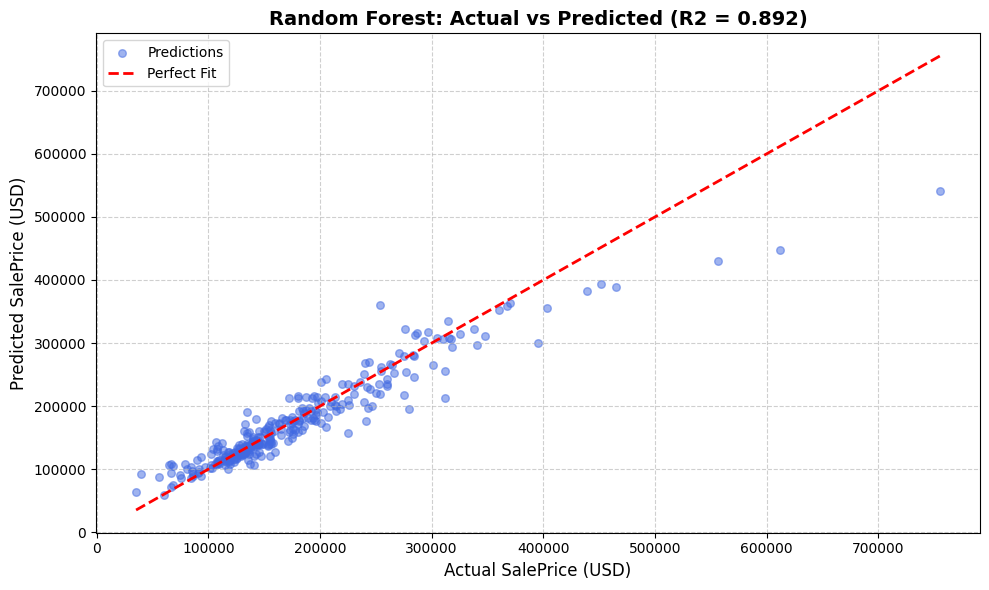

In [ ]:
X_train, X_test, y_train, y_test,le_dict = read_data()

rf_regressor = RandomForestRegressor(n_estimators=500, max_depth=12, random_state=42)
rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print("-" * 50)
print(f"✅ R2 Score: {r2:.4f}")
print(f"MAE (Mean Absolute Error): {mae:,.0f} USD")
print(f"RMSE (Root Mean Squared Error): {rmse:,.0f} USD")
print("-" * 50)

plt.figure(figsize=(10, 6))

plt.scatter(y_test_real, y_pred_real, alpha=0.5, color='royalblue', s=30, label='Predictions')

max_val = max(y_test_real.max(), y_pred_real.max())
min_val = min(y_test_real.min(), y_pred_real.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title(f'Random Forest: Actual vs Predicted (R2 = {r2:.3f})', fontsize=14, fontweight='bold')
plt.xlabel('Actual SalePrice (USD)', fontsize=12)
plt.ylabel('Predicted SalePrice (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Report_By_RandomForest.png') 
plt.show()


ERROR REPORT BY SEGMENT 'BldgType'
House Type      | Count      | MAE (USD)       | RMSE (USD)      | R2 Score  
---------------------------------------------------------------------------
1Fam            | 242        |          17,817 |          30,515 | 0.8898
2fmCon          | 2          |          19,594 |          19,757 | -0.1103
Duplex          | 11         |          10,859 |          14,820 | 0.3512
Twnhs           | 11         |          12,106 |          16,436 | 0.8122
TwnhsE          | 26         |          16,053 |          19,382 | 0.9087


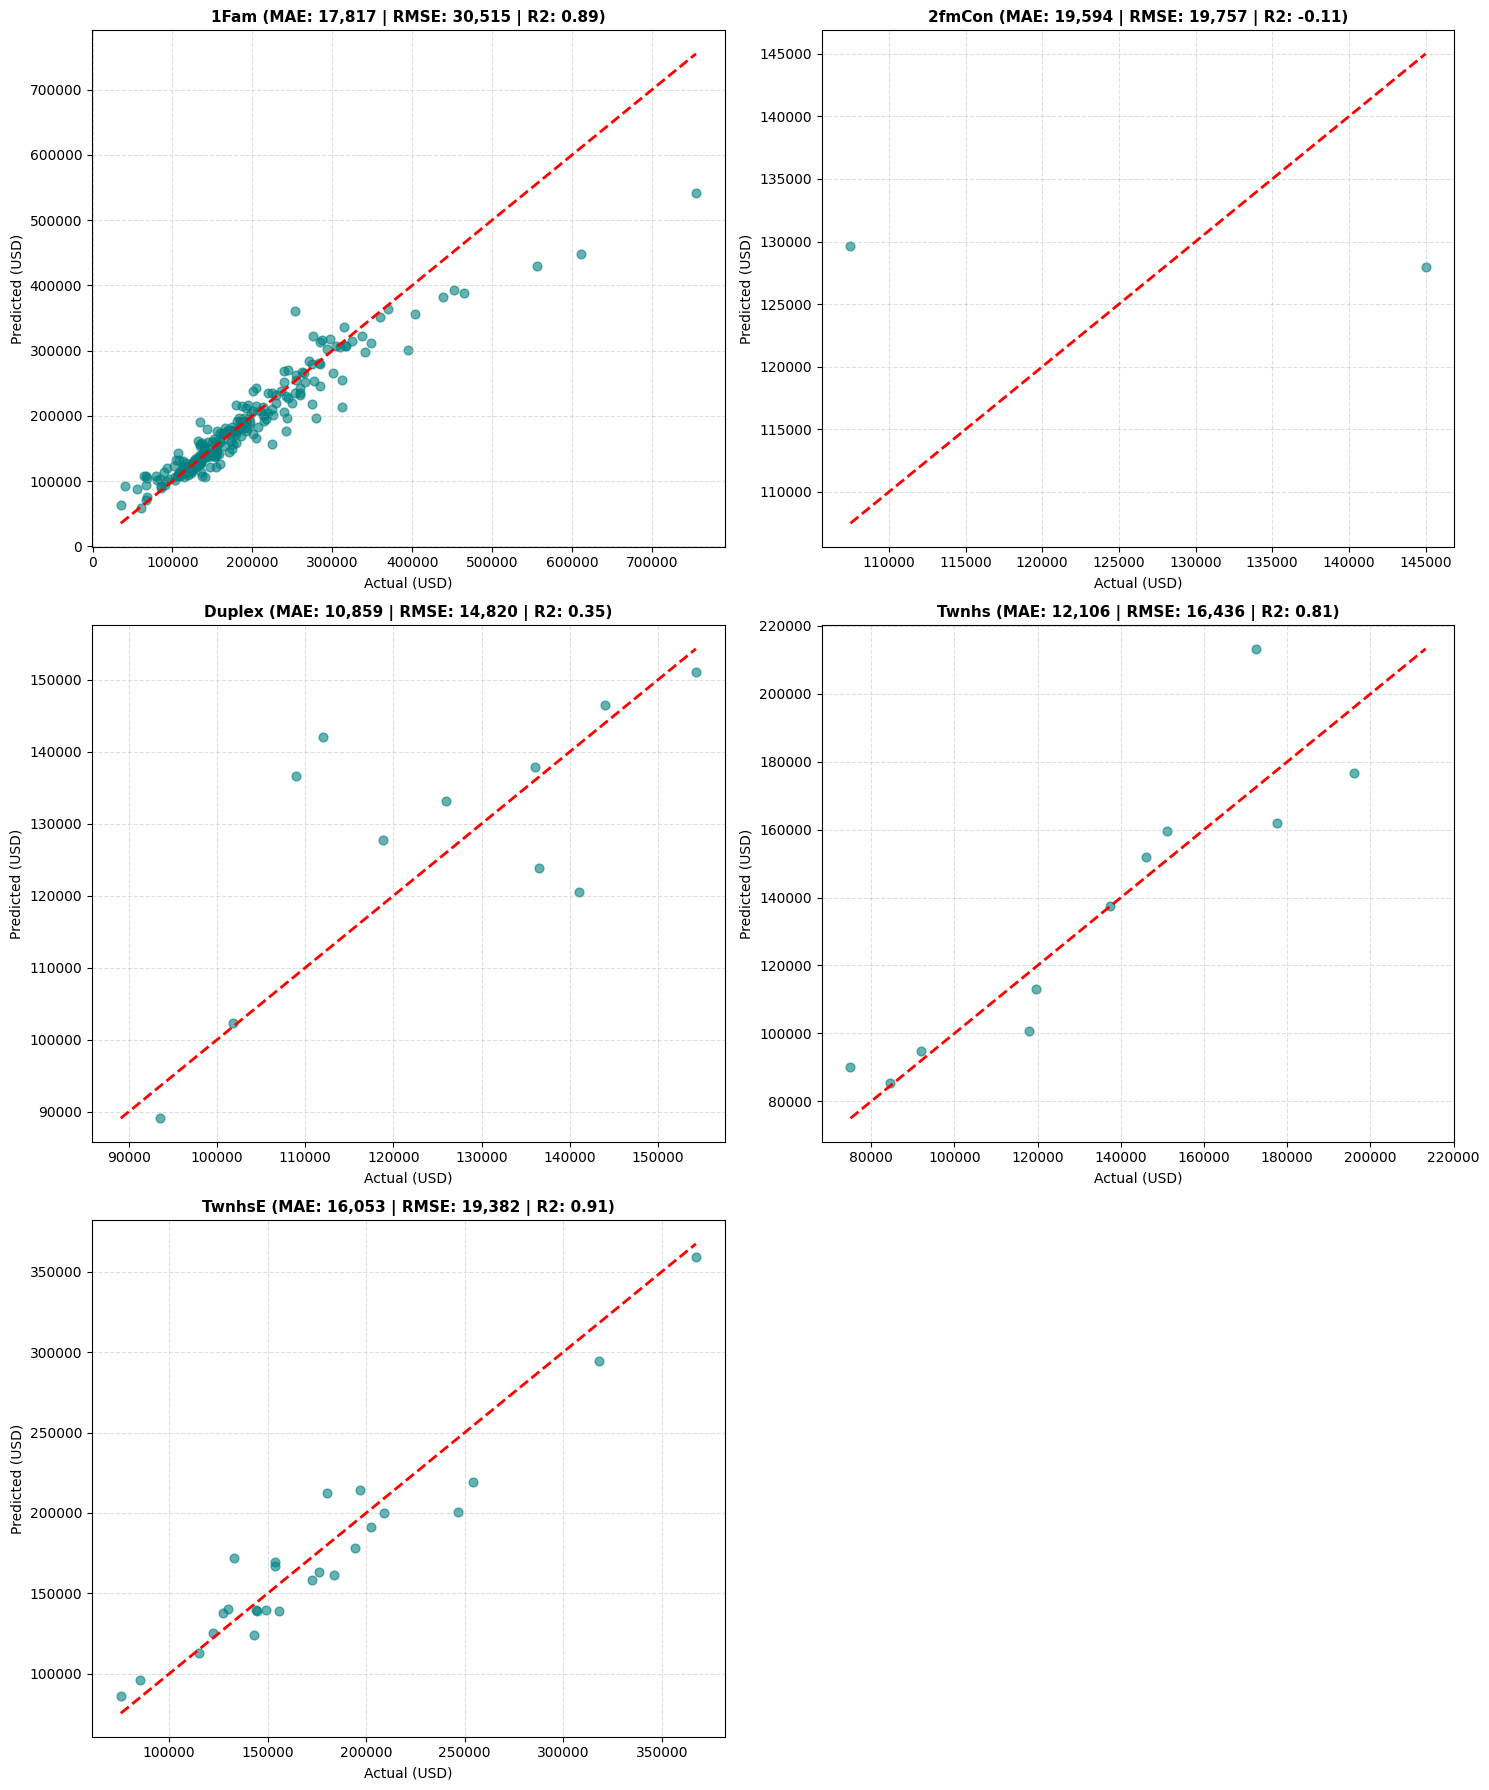

In [5]:
segment_col = 'BldgType' 

le_segment = le_dict[segment_col]

results_df = pd.DataFrame({
    'Actual': y_test_real,
    'Predicted': y_pred_real,
    'Segment_Code': X_test[segment_col] 
})

unique_segments = sorted(results_df['Segment_Code'].unique())

cols = 2
rows = (len(unique_segments) + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))

axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

print(f"\nERROR REPORT BY SEGMENT '{segment_col}'")
print(f"{'House Type':<15} | {'Count':<10} | {'MAE (USD)':<15} | {'RMSE (USD)':<15} | {'R2 Score':<10}")
print("-" * 75)

plot_idx = 0
for seg_val in unique_segments:
    mask = results_df['Segment_Code'] == seg_val
    y_t = results_df.loc[mask, 'Actual']
    y_p = results_df.loc[mask, 'Predicted']

    if len(y_t) < 2: continue 

    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)

    real_name = le_segment.categories_[0][int(seg_val)]

    print(f"{real_name:<15} | {len(y_t):<10} | {mae:15,.0f} | {rmse:15,.0f} | {r2:.4f}")

    ax = axes[plot_idx]
    ax.scatter(y_t, y_p, alpha=0.6, color='teal', s=40)

    m_val = max(y_t.max(), y_p.max())
    min_val = min(y_t.min(), y_p.min())
    ax.plot([min_val, m_val], [min_val, m_val], 'r--', linewidth=2)

    ax.set_title(f'{real_name} (MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | R2: {r2:.2f})', fontweight='bold', fontsize=11)
    ax.set_xlabel('Actual (USD)')
    ax.set_ylabel('Predicted (USD)')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plot_idx += 1

for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('House_Type_Report_random_forest.png') 
plt.show()

## **XG Boost**

In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

C:\Users\LOQ\AppData\Local\Temp\ipykernel_23928\1382494781.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_clean.select_dtypes(include=['object'])
c:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:44:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "learnign_rate", "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--------------------------------------------------
✅ R2 Score: 0.9039
MAE (Mean Absolute Error): 16,719 USD
RMSE (Root Mean Squared Error): 27,144 USD
--------------------------------------------------


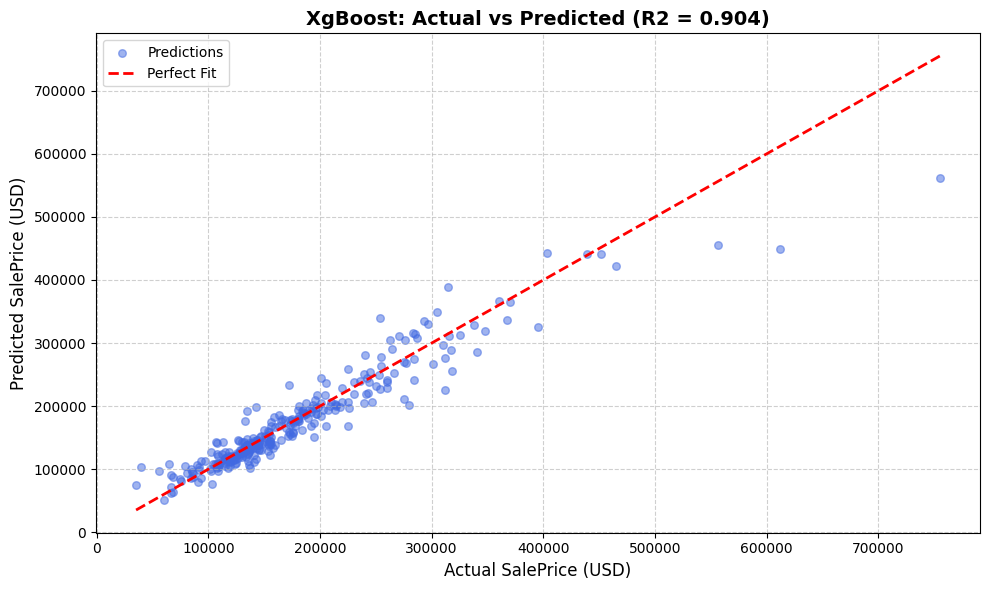

In [25]:
X_train, X_test, y_train, y_test,le_dict = read_data()

xgb_regressor = XGBRegressor(
    n_estimators=500,
    num_leaves=31,
    max_depth=5,
    random_state=42,
    learnign_rate=0.05,
    objective='reg:squarederror'
    )

xgb_regressor.fit(X_train, y_train)

y_pred=xgb_regressor.predict(X_test)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print("-" * 50)
print(f"✅ R2 Score: {r2:.4f}")
print(f"MAE (Mean Absolute Error): {mae:,.0f} USD")
print(f"RMSE (Root Mean Squared Error): {rmse:,.0f} USD")
print("-" * 50)

plt.figure(figsize=(10, 6))

plt.scatter(y_test_real, y_pred_real, alpha=0.5, color='royalblue', s=30, label='Predictions')

max_val = max(y_test_real.max(), y_pred_real.max())
min_val = min(y_test_real.min(), y_pred_real.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title(f'XgBoost: Actual vs Predicted (R2 = {r2:.3f})', fontsize=14, fontweight='bold')
plt.xlabel('Actual SalePrice (USD)', fontsize=12)
plt.ylabel('Predicted SalePrice (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Report_By_XgBoost.png') 
plt.show()


ERROR REPORT BY SEGMENT 'BldgType'
House Type      | Count      | MAE (USD)       | RMSE (USD)      | R2 Score  
---------------------------------------------------------------------------
1Fam            | 242        |          17,010 |          28,255 | 0.9055
2fmCon          | 2          |          23,346 |          25,508 | -0.8507
Duplex          | 11         |          10,180 |          12,770 | 0.5183
Twnhs           | 11         |          11,964 |          19,844 | 0.7263
TwnhsE          | 26         |          18,280 |          23,634 | 0.8642


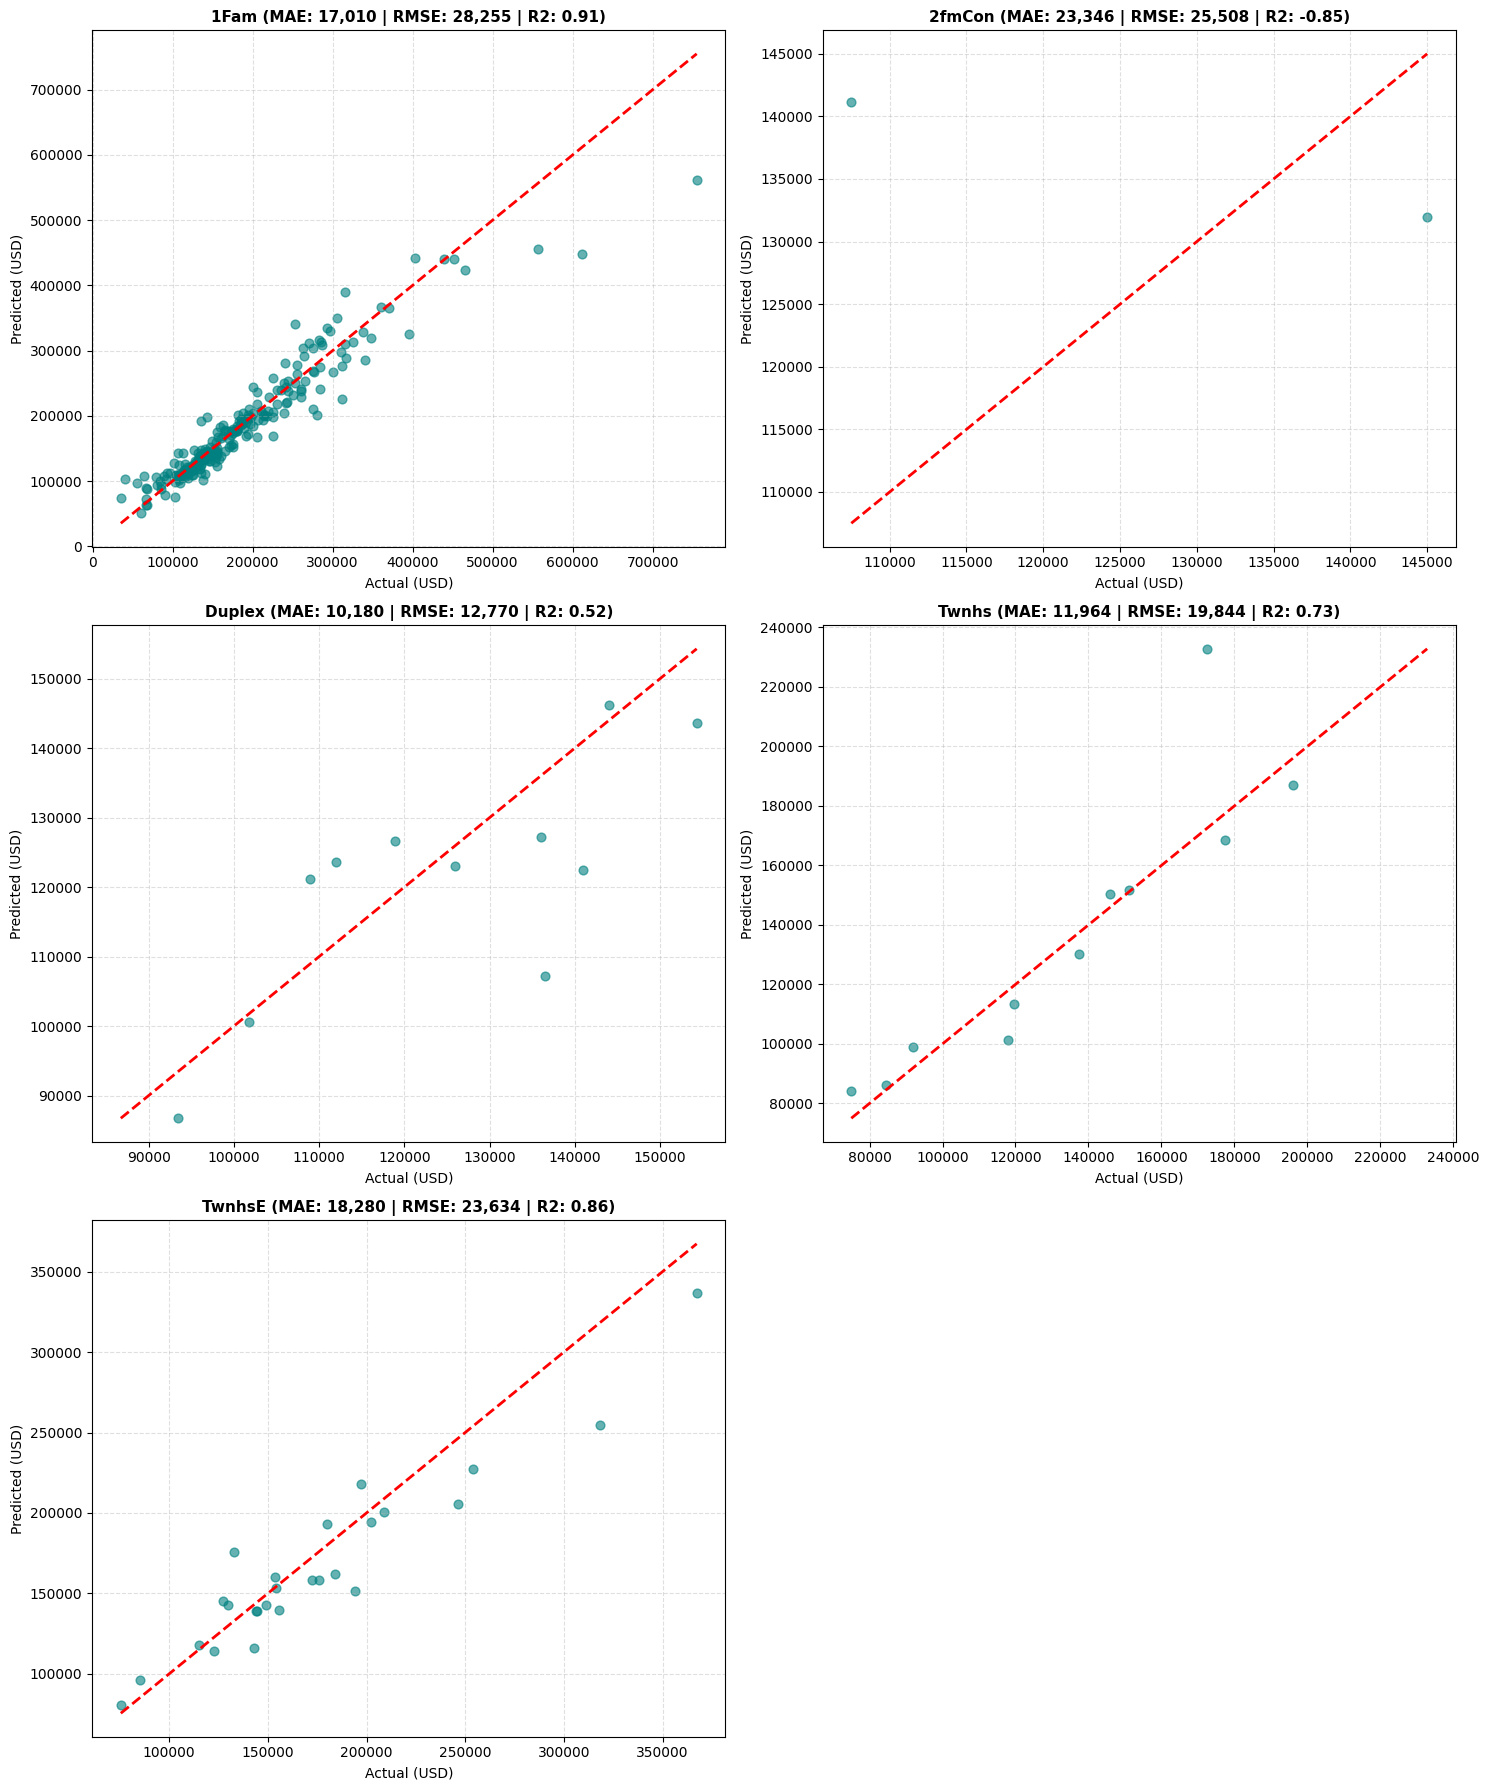

In [8]:
segment_col = 'BldgType' 

le_segment = le_dict[segment_col]

results_df = pd.DataFrame({
    'Actual': y_test_real,
    'Predicted': y_pred_real,
    'Segment_Code': X_test[segment_col] 
})

unique_segments = sorted(results_df['Segment_Code'].unique())

cols = 2
rows = (len(unique_segments) + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))

axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

print(f"\nERROR REPORT BY SEGMENT '{segment_col}'")
print(f"{'House Type':<15} | {'Count':<10} | {'MAE (USD)':<15} | {'RMSE (USD)':<15} | {'R2 Score':<10}")
print("-" * 75)

plot_idx = 0
for seg_val in unique_segments:
    mask = results_df['Segment_Code'] == seg_val
    y_t = results_df.loc[mask, 'Actual']
    y_p = results_df.loc[mask, 'Predicted']

    if len(y_t) < 2: continue 

    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)

    real_name = le_segment.categories_[0][int(seg_val)]

    print(f"{real_name:<15} | {len(y_t):<10} | {mae:15,.0f} | {rmse:15,.0f} | {r2:.4f}")

    ax = axes[plot_idx]
    ax.scatter(y_t, y_p, alpha=0.6, color='teal', s=40)

    m_val = max(y_t.max(), y_p.max())
    min_val = min(y_t.min(), y_p.min())
    ax.plot([min_val, m_val], [min_val, m_val], 'r--', linewidth=2)

    ax.set_title(f'{real_name} (MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | R2: {r2:.2f})', fontweight='bold', fontsize=11)
    ax.set_xlabel('Actual (USD)')
    ax.set_ylabel('Predicted (USD)')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plot_idx += 1

for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('House_Type_Report_Xg_Boost.png') 
plt.show()

## **SVR**

In [9]:
from sklearn.svm import SVR 
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

C:\Users\LOQ\AppData\Local\Temp\ipykernel_23928\1321570757.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_clean.select_dtypes(include=['object']).columns


--------------------------------------------------
✅ R2 Score: 0.8328
MAE (Mean Absolute Error): 19,071 USD
RMSE (Root Mean Squared Error): 35,813 USD
--------------------------------------------------


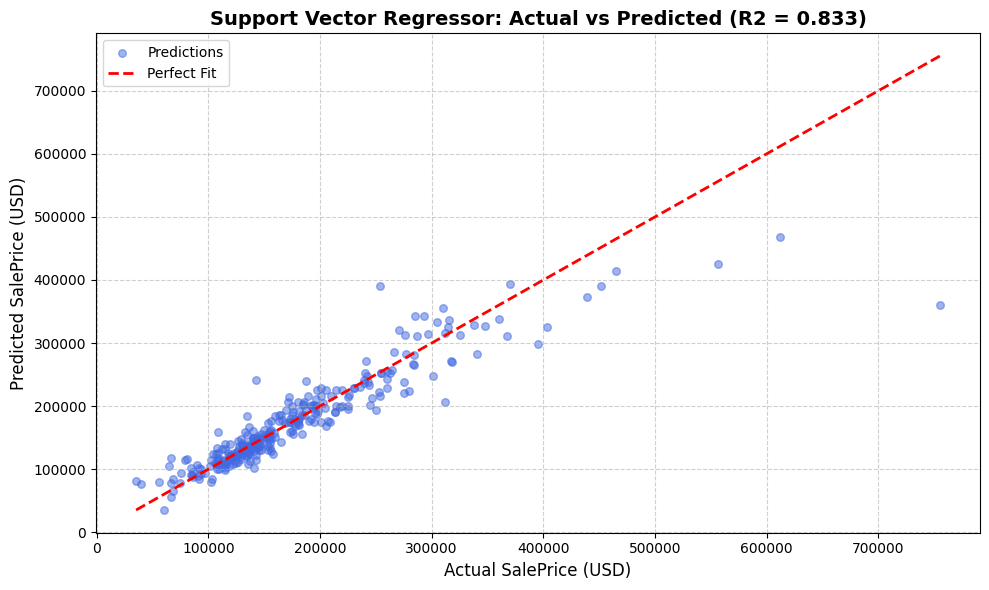

In [10]:
df=pd.read_csv(r"C:\Users\LOQ\Downloads\Exercise\ADY\house-prices-advanced-regression-techniques\train.csv")
X_clean,y_clean=cleaning_data(df)
num_cols = X_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_clean.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=50)),
    ('model', SVR(kernel='rbf', C=10, epsilon=0.01, gamma='scale'))
])

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

svm_pipeline.fit(X_train,y_train)

y_pred=svm_pipeline.predict(X_test)
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print("-" * 50)
print(f"✅ R2 Score: {r2:.4f}")
print(f"MAE (Mean Absolute Error): {mae:,.0f} USD")
print(f"RMSE (Root Mean Squared Error): {rmse:,.0f} USD")
print("-" * 50)

plt.figure(figsize=(10, 6))

plt.scatter(y_test_real, y_pred_real, alpha=0.5, color='royalblue', s=30, label='Predictions')

max_val = max(y_test_real.max(), y_pred_real.max())
min_val = min(y_test_real.min(), y_pred_real.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title(f'Support Vector Regressor: Actual vs Predicted (R2 = {r2:.3f})', fontsize=14, fontweight='bold')
plt.xlabel('Actual SalePrice (USD)', fontsize=12)
plt.ylabel('Predicted SalePrice (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Report_By_SVR.png') 
plt.show()





ERROR REPORT BY SEGMENT 'BldgType'
House Type      | Count      | MAE (USD)       | RMSE (USD)      | R2 Score  
---------------------------------------------------------------------------
1Fam            | 242        |          19,760 |          38,129 | 0.8279
2fmCon          | 2          |          13,843 |          18,899 | -0.0160
Duplex          | 11         |          10,087 |          17,146 | 0.1316
Twnhs           | 11         |          10,781 |          15,580 | 0.8313
TwnhsE          | 26         |          20,367 |          24,856 | 0.8498


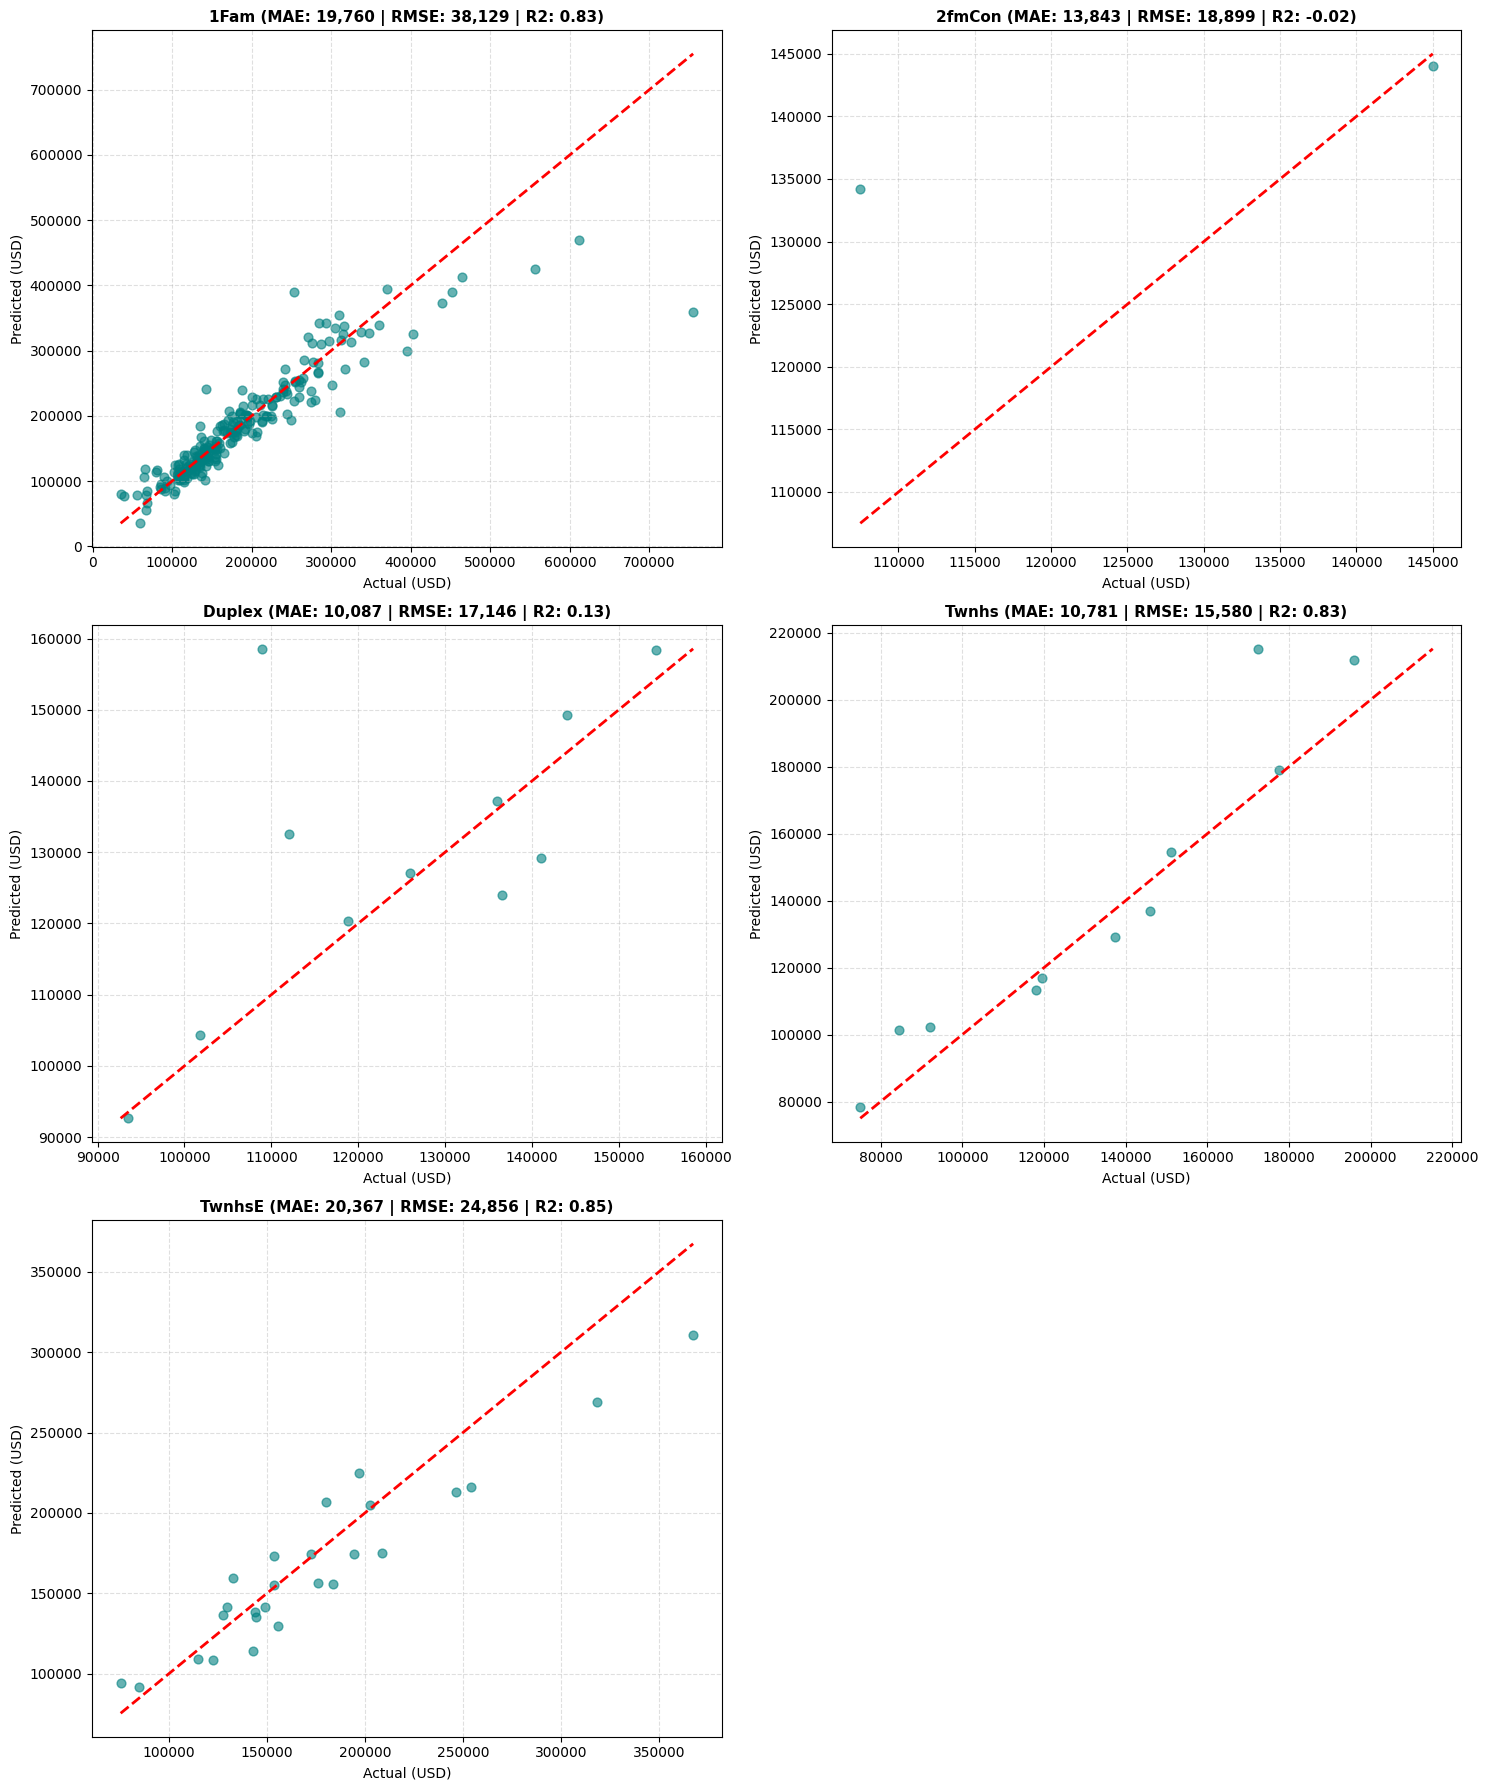

In [11]:
segment_col = 'BldgType' 


results_df = pd.DataFrame({
    'Actual': y_test_real,
    'Predicted': y_pred_real,
    'Segment_Name': X_test[segment_col].values 
})


unique_segments = sorted(results_df['Segment_Name'].unique())

cols = 2
rows = (len(unique_segments) + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

print(f"\nERROR REPORT BY SEGMENT '{segment_col}'")
print(f"{'House Type':<15} | {'Count':<10} | {'MAE (USD)':<15} | {'RMSE (USD)':<15} | {'R2 Score':<10}")
print("-" * 75)

plot_idx = 0
for seg_name in unique_segments:
    
    mask = results_df['Segment_Name'] == seg_name
    y_t = results_df.loc[mask, 'Actual']
    y_p = results_df.loc[mask, 'Predicted']

    if len(y_t) < 2: continue 

    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)

    
    print(f"{seg_name:<15} | {len(y_t):<10} | {mae:15,.0f} | {rmse:15,.0f} | {r2:.4f}")

    ax = axes[plot_idx]
    ax.scatter(y_t, y_p, alpha=0.6, color='teal', s=40)

    m_val = max(y_t.max(), y_p.max())
    min_val = min(y_t.min(), y_p.min())
    ax.plot([min_val, m_val], [min_val, m_val], 'r--', linewidth=2)

    ax.set_title(f'{seg_name} (MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | R2: {r2:.2f})', fontweight='bold', fontsize=11)
    ax.set_xlabel('Actual (USD)')
    ax.set_ylabel('Predicted (USD)')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plot_idx += 1

for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('House_Type_Report_SVR.png') 
plt.show()

## **LightGBM**

In [12]:
import lightgbm as lgb

C:\Users\LOQ\AppData\Local\Temp\ipykernel_23928\1382494781.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_clean.select_dtypes(include=['object'])


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001020 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2441
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 64
[LightGBM] [Info] Start training from score 12.030658
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

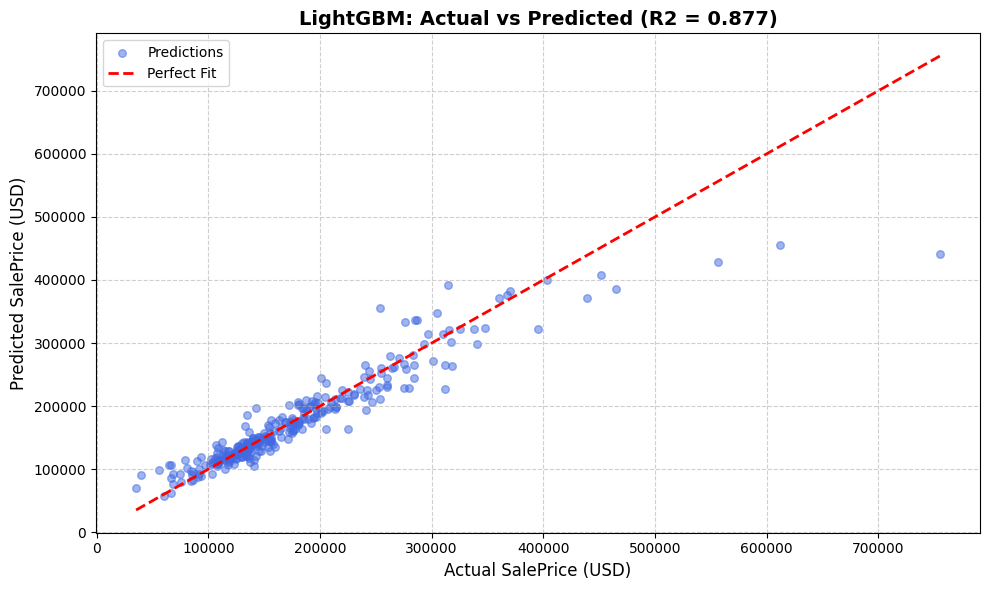

In [13]:
X_train, X_test, y_train, y_test, le_dict = read_data()

lgb_regressor = lgb.LGBMRegressor(
    n_estimators=500,
    num_leaves=31,
    max_depth=5,
    random_state=42,
    learning_rate=0.01,
    objective='regression',
    n_jobs=-1
)

lgb_regressor.fit(X_train, y_train)

y_pred = lgb_regressor.predict(X_test)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print("-" * 50)
print(f"✅ R2 Score: {r2:.4f}")
print(f"MAE (Mean Absolute Error): {mae:,.0f} USD")
print(f"RMSE (Root Mean Squared Error): {rmse:,.0f} USD")
print("-" * 50)

plt.figure(figsize=(10, 6))

plt.scatter(y_test_real, y_pred_real, alpha=0.5, color='royalblue', s=30, label='Predictions')

max_val = max(y_test_real.max(), y_pred_real.max())
min_val = min(y_test_real.min(), y_pred_real.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title(f'LightGBM: Actual vs Predicted (R2 = {r2:.3f})', fontsize=14, fontweight='bold')
plt.xlabel('Actual SalePrice (USD)', fontsize=12)
plt.ylabel('Predicted SalePrice (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Report_By_LightGBM.png') 
plt.show()


ERROR REPORT BY SEGMENT 'BldgType'
House Type      | Count      | MAE (USD)       | RMSE (USD)      | R2 Score  
---------------------------------------------------------------------------
0.0             | 242        |          17,161 |          32,793 | 0.8727
1.0             | 2          |          13,775 |          13,908 | 0.4498
2.0             | 11         |          12,639 |          16,397 | 0.2058
3.0             | 11         |           9,173 |          12,242 | 0.8958
4.0             | 26         |          15,803 |          20,502 | 0.8978


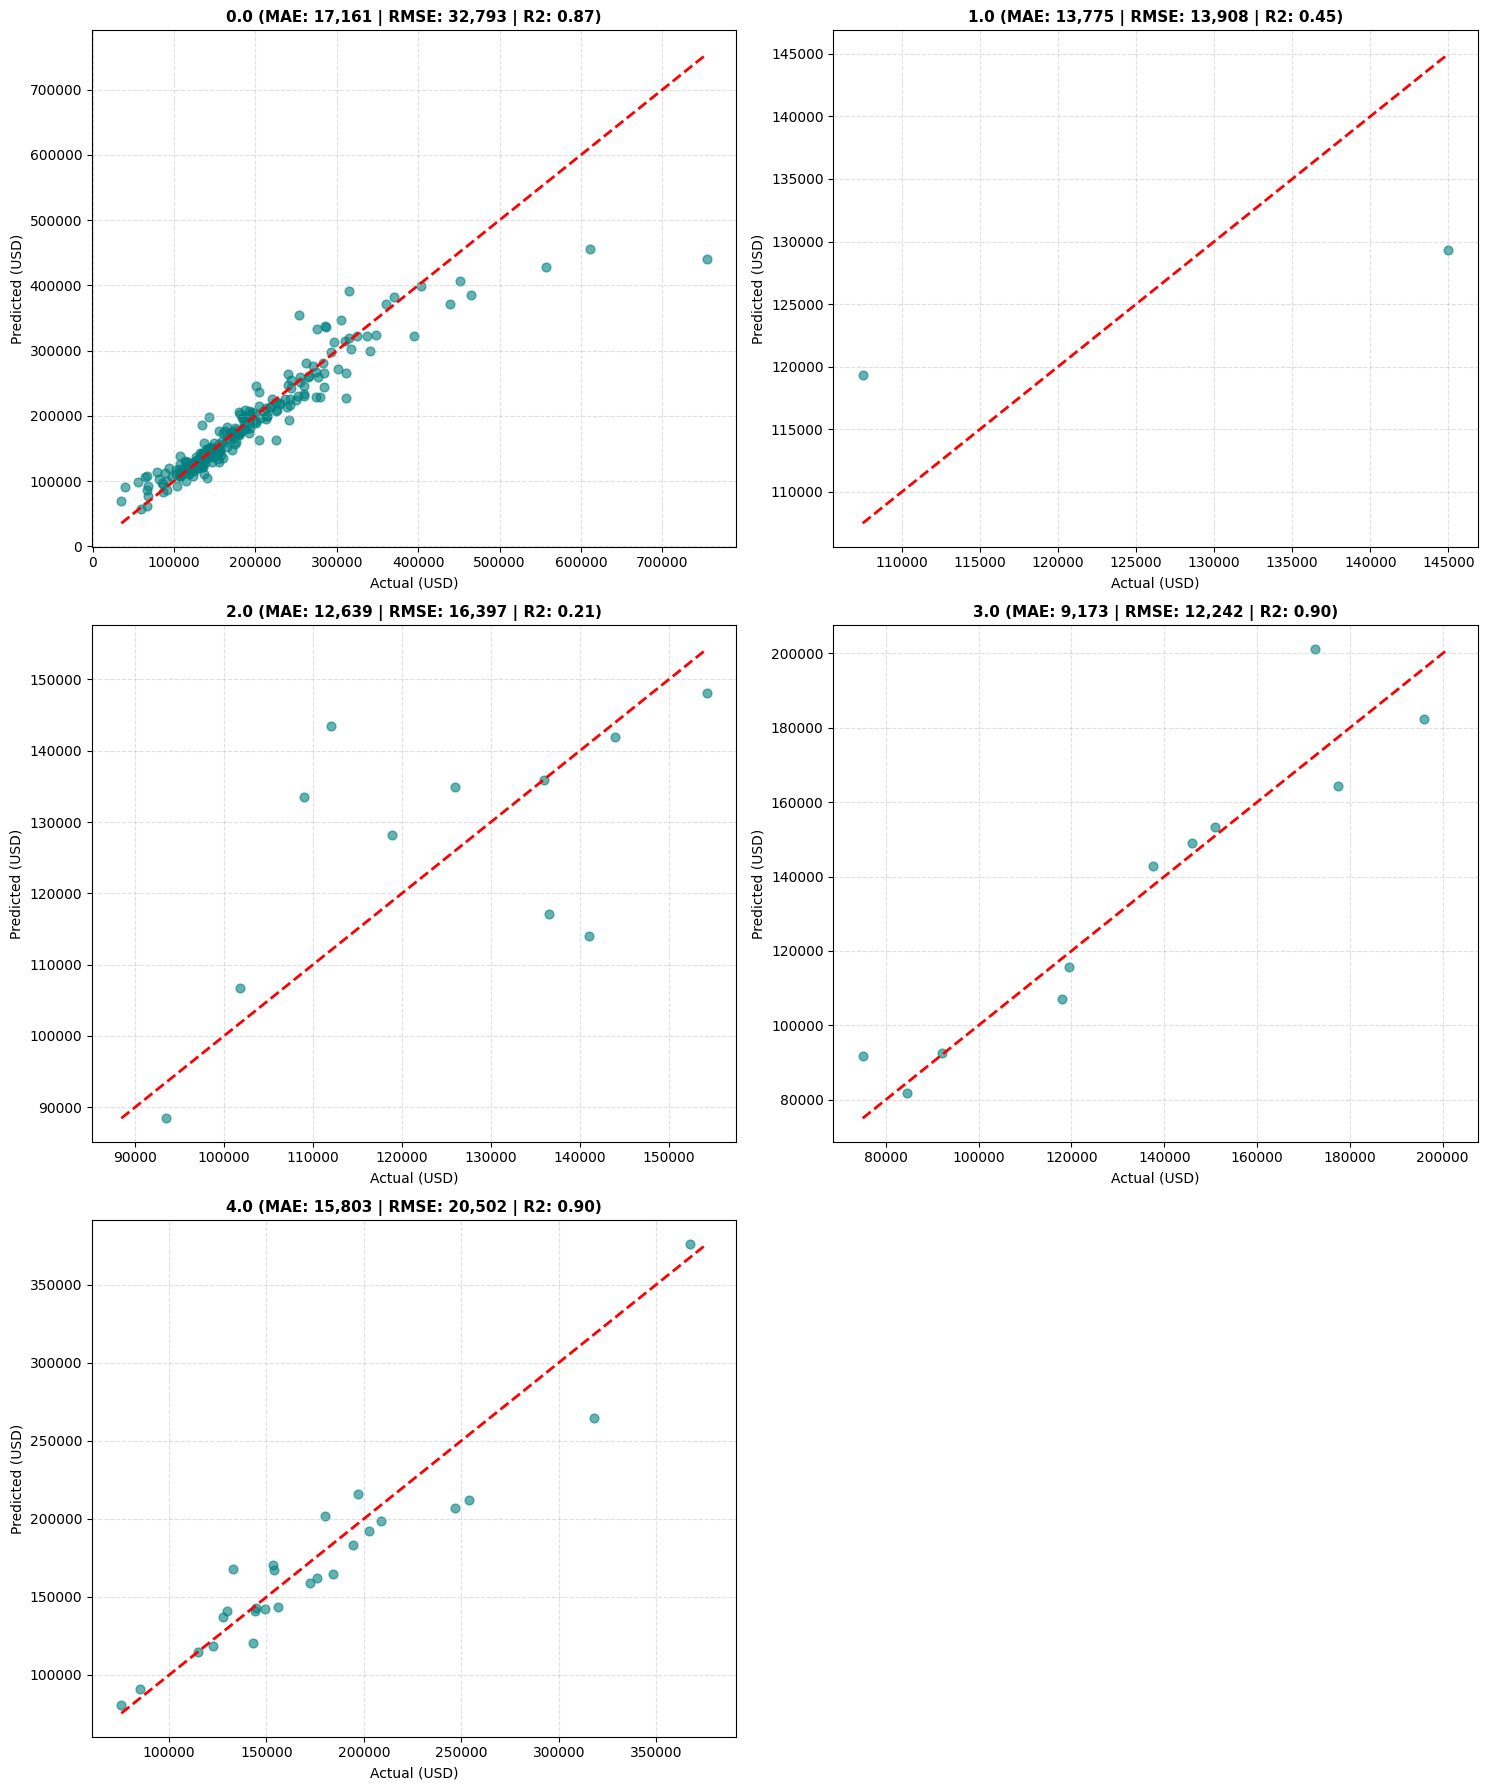

In [14]:
segment_col = 'BldgType' 

results_df = pd.DataFrame({
    'Actual': y_test_real,
    'Predicted': y_pred_real,
    'Segment_Name': X_test[segment_col].values 
})

unique_segments = sorted(results_df['Segment_Name'].unique())

cols = 2
rows = (len(unique_segments) + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

print(f"\nERROR REPORT BY SEGMENT '{segment_col}'")
print(f"{'House Type':<15} | {'Count':<10} | {'MAE (USD)':<15} | {'RMSE (USD)':<15} | {'R2 Score':<10}")
print("-" * 75)

plot_idx = 0
for seg_name in unique_segments:
    mask = results_df['Segment_Name'] == seg_name
    y_t = results_df.loc[mask, 'Actual']
    y_p = results_df.loc[mask, 'Predicted']

    if len(y_t) < 2: continue 

    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)

    print(f"{seg_name:<15} | {len(y_t):<10} | {mae:15,.0f} | {rmse:15,.0f} | {r2:.4f}")

    ax = axes[plot_idx]
    ax.scatter(y_t, y_p, alpha=0.6, color='teal', s=40)

    m_val = max(y_t.max(), y_p.max())
    min_val = min(y_t.min(), y_p.min())
    ax.plot([min_val, m_val], [min_val, m_val], 'r--', linewidth=2)

    ax.set_title(f'{seg_name} (MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | R2: {r2:.2f})', fontweight='bold', fontsize=11)
    ax.set_xlabel('Actual (USD)')
    ax.set_ylabel('Predicted (USD)')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plot_idx += 1

for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('House_Type_Report_LightGBM.png') 
plt.show()

## **AdaBoost**

In [15]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

C:\Users\LOQ\AppData\Local\Temp\ipykernel_23928\1382494781.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_clean.select_dtypes(include=['object'])


--------------------------------------------------
✅ R2 Score: 0.8796
 MAE (Mean Absolute Error): 18,799 USD
 RMSE (Root Mean Squared Error): 30,389 USD
--------------------------------------------------


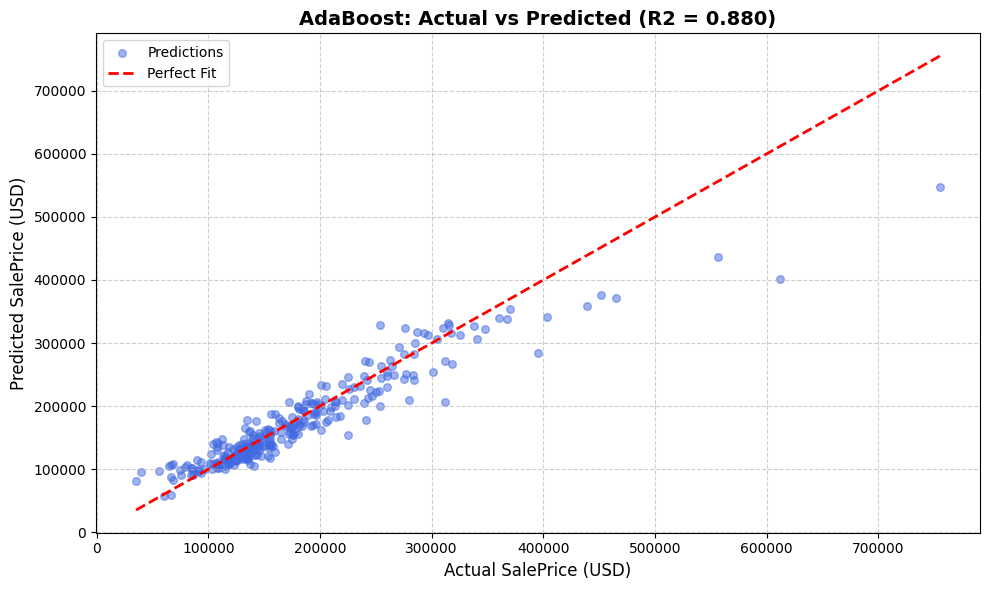

In [24]:
X_train, X_test, y_train, y_test,le_dict = read_data()
Ada_model=AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=5), 
    n_estimators=500,
    learning_rate=0.05, 
    random_state=42
)

Ada_model.fit(X_train,y_train)
y_pred=Ada_model.predict(X_test)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print("-" * 50)
print(f"✅ R2 Score: {r2:.4f}")
print(f" MAE (Mean Absolute Error): {mae:,.0f} USD")
print(f" RMSE (Root Mean Squared Error): {rmse:,.0f} USD")
print("-" * 50)

plt.figure(figsize=(10, 6))

plt.scatter(y_test_real, y_pred_real, alpha=0.5, color='royalblue', s=30, label='Predictions')

max_val = max(y_test_real.max(), y_pred_real.max())
min_val = min(y_test_real.min(), y_pred_real.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title(f'AdaBoost: Actual vs Predicted (R2 = {r2:.3f})', fontsize=14, fontweight='bold')
plt.xlabel('Actual SalePrice (USD)', fontsize=12)
plt.ylabel('Predicted SalePrice (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Report_By_AdaBoost.png') 
plt.show()


ERROR REPORT BY SEGMENT 'BldgType'
House Type      | Count      | MAE (USD)       | RMSE (USD)      | R2 Score  
---------------------------------------------------------------------------
1Fam            | 242        |          17,817 |          30,515 | 0.8898
2fmCon          | 2          |          19,594 |          19,757 | -0.1103
Duplex          | 11         |          10,859 |          14,820 | 0.3512
Twnhs           | 11         |          12,106 |          16,436 | 0.8122
TwnhsE          | 26         |          16,053 |          19,382 | 0.9087


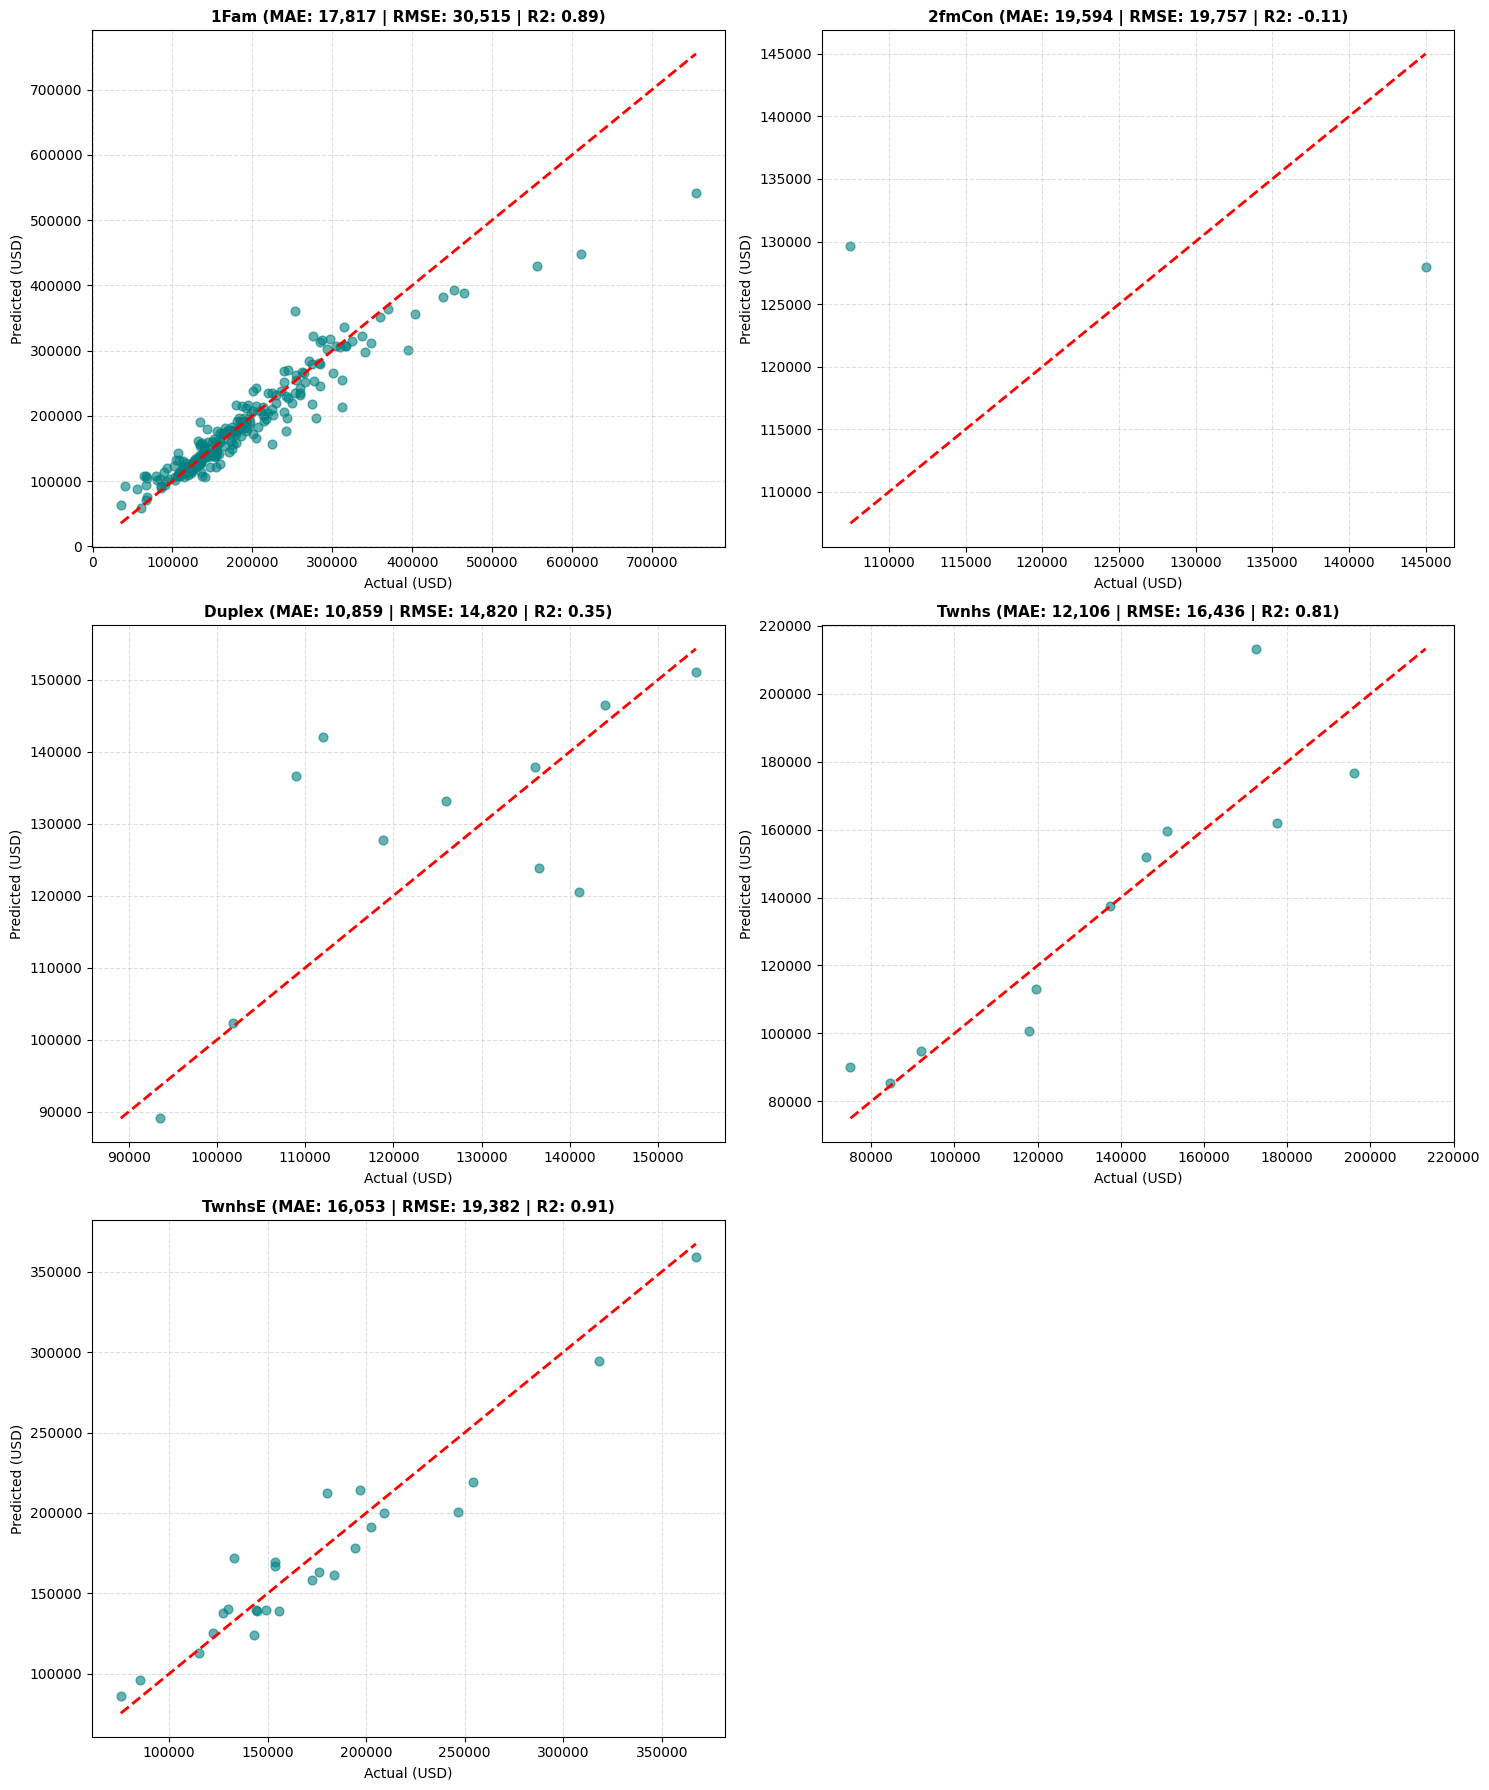

In [23]:
segment_col = 'BldgType' 

le_segment = le_dict[segment_col]

results_df = pd.DataFrame({
    'Actual': y_test_real,
    'Predicted': y_pred_real,
    'Segment_Code': X_test[segment_col] 
})

unique_segments = sorted(results_df['Segment_Code'].unique())

cols = 2
rows = (len(unique_segments) + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))

axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

print(f"\nERROR REPORT BY SEGMENT '{segment_col}'")
print(f"{'House Type':<15} | {'Count':<10} | {'MAE (USD)':<15} | {'RMSE (USD)':<15} | {'R2 Score':<10}")
print("-" * 75)

plot_idx = 0
for seg_val in unique_segments:
    mask = results_df['Segment_Code'] == seg_val
    y_t = results_df.loc[mask, 'Actual']
    y_p = results_df.loc[mask, 'Predicted']

    if len(y_t) < 2: continue 

    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)

    real_name = le_segment.categories_[0][int(seg_val)]

    print(f"{real_name:<15} | {len(y_t):<10} | {mae:15,.0f} | {rmse:15,.0f} | {r2:.4f}")

    ax = axes[plot_idx]
    ax.scatter(y_t, y_p, alpha=0.6, color='teal', s=40)

    m_val = max(y_t.max(), y_p.max())
    min_val = min(y_t.min(), y_p.min())
    ax.plot([min_val, m_val], [min_val, m_val], 'r--', linewidth=2)

    ax.set_title(f'{real_name} (MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | R2: {r2:.2f})', fontweight='bold', fontsize=11)
    ax.set_xlabel('Actual (USD)')
    ax.set_ylabel('Predicted (USD)')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plot_idx += 1

for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('House_Type_Report_AdaBoost.png') 
plt.show()

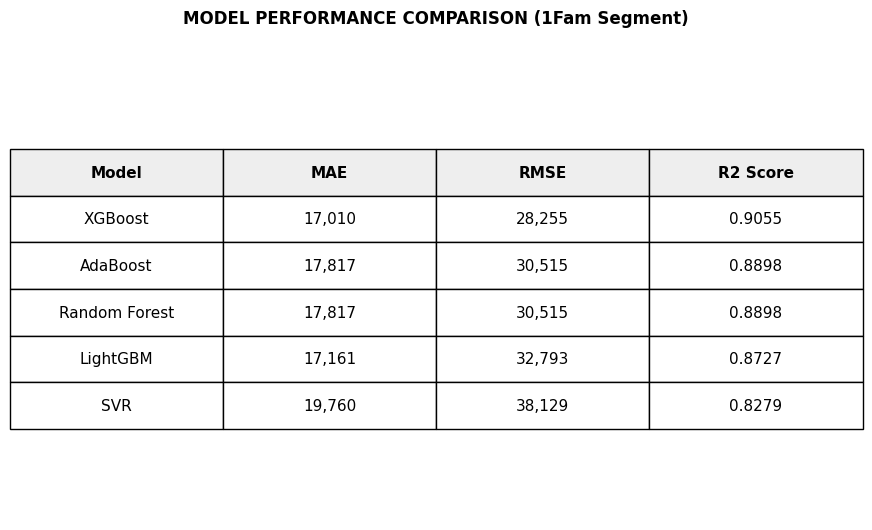

File saved: House_Type_1Fam_Comparison.png


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

def draw_black_white_table():
    data = {
        'Model': [
            'AdaBoost', 
            'LightGBM', 
            'SVR', 
            'XGBoost', 
            'Random Forest'
        ],
        'MAE': [
            '17,817', 
            '17,161', 
            '19,760', 
            '17,010', 
            '17,817'  
        ],
        'RMSE': [
            '30,515', 
            '32,793', 
            '38,129', 
            '28,255', 
            '30,515'
        ],
        'R2 Score': [0.8898, 0.8727, 0.8279, 0.9055, 0.8898]
    }

    df = pd.DataFrame(data)

    df = df.sort_values(by='R2 Score', ascending=False)

    df['R2 Score'] = df['R2 Score'].map(lambda x: f"{x:.4f}")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='center',
        colColours=['#eeeeee']*4
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.1, 2.8)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.get_text().set_weight('bold')
        cell.set_linewidth(1)

    plt.title('MODEL PERFORMANCE COMPARISON (1Fam Segment)', fontsize=12, pad=25, weight='bold')

    plt.savefig('House_Type_1Fam_Comparison.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("File saved: House_Type_1Fam_Comparison.png")

if __name__ == "__main__":
    draw_black_white_table()